<a href="https://colab.research.google.com/github/riyadey08/riyasfirstrepo/blob/main/facesearch_mvp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**install dependencies**

In [ ]:
!pip install insightface onnxruntime opencv-python faiss-cpu

**upload image**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving selfie1.jpeg to selfie1 (1).jpeg


**load images**


(np.float64(-0.5), np.float64(1064.5), np.float64(991.5), np.float64(-0.5))

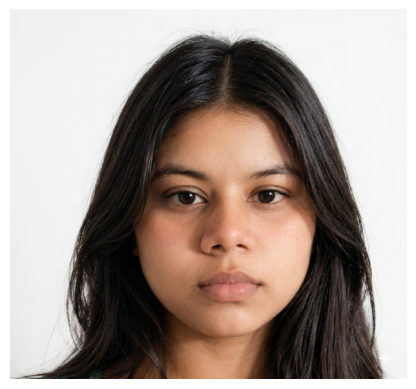

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("selfie1.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

**Initialize InsightFace**

In [ ]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0)

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: [(128, 128), (640, 640)

In [ ]:
faces = app.get(img)

print(faces)

[{'bbox': array([335.57477, 255.99823, 820.1365 , 871.4219 ], dtype=float32), 'kps': array([[465.04547, 505.4937 ],
       [709.3189 , 502.41367],
       [591.236  , 613.82294],
       [495.03275, 744.2176 ],
       [675.81006, 741.1281 ]], dtype=float32), 'det_score': np.float32(0.8998648), 'landmark_3d_68': array([[ 3.28831696e+02,  4.90803894e+02,  3.25977203e+02],
       [ 3.37517151e+02,  5.59424561e+02,  3.24367340e+02],
       [ 3.47690338e+02,  6.29674255e+02,  3.17212891e+02],
       [ 3.61490570e+02,  6.96021606e+02,  2.98547363e+02],
       [ 3.83261139e+02,  7.56431519e+02,  2.50715836e+02],
       [ 4.16998169e+02,  8.00969482e+02,  2.07720993e+02],
       [ 4.59380585e+02,  8.32672607e+02,  1.71803879e+02],
       [ 5.08746765e+02,  8.57540344e+02,  1.25258820e+02],
       [ 5.84659546e+02,  8.77543396e+02,  1.01523254e+02],
       [ 6.58544373e+02,  8.57416016e+02,  1.31994217e+02],
       [ 7.12096619e+02,  8.26977539e+02,  1.85965103e+02],
       [ 7.55494690e+02,  7.8

**Extract Embedding**

In [ ]:
embedding1 = faces[0].embedding

print(embedding1.shape)

(512,)


**compare with the first embedding vector**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving selfie4.jpeg to selfie4 (1).jpeg
Saving selfie3.jpeg to selfie3 (1).jpeg
Saving selfie2.jpeg to selfie2 (1).jpeg


In [ ]:
import cv2

img2 = cv2.imread("selfie2.jpeg")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img3 = cv2.imread("selfie3.jpeg")
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

img4 = cv2.imread("selfie4.jpeg")
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)



In [ ]:
faces2 = app.get(img2)

embedding2 = faces2[0].embedding

faces3 = app.get(img3)

embedding3 = faces3[0].embedding

faces4 = app.get(img4)

embedding4 = faces4[0].embedding

**cosine similarity comparison with first embedding vector**

In [ ]:
import numpy as np
from numpy.linalg import norm

embeddings = [embedding1, embedding2, embedding3, embedding4]

for i in range(len(embeddings)):
    for j in range(i + 1, len(embeddings)):

        similarity = np.dot(embeddings[i], embeddings[j]) / (
            norm(embeddings[i]) * norm(embeddings[j])
        )

        print(f"Similarity between Image{i+1} and Image{j+1}: {similarity}")

Similarity between Image1 and Image2: 0.6655970215797424
Similarity between Image1 and Image3: 0.6184229254722595
Similarity between Image1 and Image4: 0.6031035780906677
Similarity between Image2 and Image3: 0.7657581567764282
Similarity between Image2 and Image4: 0.7017664313316345
Similarity between Image3 and Image4: 0.6916835904121399


**import multiple images**

In [ ]:
from google.colab import files

uploaded1 = files.upload()

Saving faces_zip.zip to faces_zip (2).zip


In [ ]:
import zipfile

filename = list(uploaded1.keys())[0]

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("faces_dataset")

In [ ]:
import os
print(os.listdir("faces_dataset"))

['faces']


**remove duplicates**

In [ ]:
import hashlib

def get_md5(file_path):
    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()

seen_hashes = set()

In [ ]:
new_hash = get_md5("faces_zip.zip")

if new_hash in seen_hashes:
    print("Duplicate image detected. Skipping.")
else:
    seen_hashes.add(new_hash)

**removing Blurry images ,Very small faces, No face detected,Extremely dark or bright photos,Low-resolution images**

In [ ]:
def blur_score(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    score = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    return score


def classify_blur(image_path):

    score = blur_score(image_path)

    if score is None:
        return "invalid", 0

    # Tuned for typical event photos
    if score < 50:
        return "reject", score

    elif score < 120:
        return "borderline", score

    else:
        return "accept", score

In [ ]:
image_folder = "/content/faces_dataset/faces"

for filename in os.listdir(image_folder):

    path = os.path.join(image_folder, filename)
    score = blur_score(path)

    if score < 100:
        continue

    print(filename)

images (8).jpeg
images (9).jpeg
images (11).jpeg
download (1).jpeg
images (13).jpeg
download.jpeg
download (2).jpeg
images (48).jpeg
images (12).jpeg
images (5).jpeg
download (7).jpeg
images (4).jpeg
download (5).jpeg
download (4).jpeg
images (2).jpeg
images (1).jpeg
images (3).jpeg
download (3).jpeg
download (6).jpeg
images (6).jpeg
images.jpeg
download (8).jpeg
images (10).jpeg
images (7).jpeg


In [ ]:
#no faces
faces = app.get(img)

if len(faces) == 0:
    print("No face detected")

In [ ]:
#tiny faces
for face in faces:

    x1, y1, x2, y2 = face.bbox.astype(int)

    width = x2 - x1
    height = y2 - y1

    if width < 80 or height < 80:
        continue

In [ ]:
#brightness
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

brightness = gray.mean()

white_pixels = np.sum(gray > 245)

ratio = white_pixels / gray.size

if ratio > 0.3:
    print("Overexposed")

if brightness < 40 and ratio > 0.3:
    print("Too dark")

elif brightness > 220:
    print("Too bright")



**accepted images**

In [ ]:
accepted_images = []
accepted_images.append(filename)

print(f"Accepted: {filename}")


Accepted: images (7).jpeg


**genarate embeddings**

In [ ]:
embeddings = []
image_names = []

folder = "faces_dataset/faces"

for filename in os.listdir(folder):

    path = os.path.join(folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = app.get(img)

    if len(faces) == 0:
        continue

    embedding = faces[0].embedding

    embeddings.append(embedding)
    image_names.append(filename)

print("Processed:", len(embeddings))

Processed: 23


**convert embeddings to array**

In [ ]:
embeddings = np.array(embeddings)

print(embeddings.shape)

(23, 512)


**create FAISS index**

In [ ]:
!pip install faiss-cpu

import faiss

faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("Indexed faces:", index.ntotal)

Indexed faces: 23


**Automatic Face Clustering (DBSCAN)**

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,
    metric='euclidean'
)

labels = clusterer.fit_predict(embeddings)

In [ ]:
{
    "face_embedding": embeddings,
    "image_path": image_names
}

{'face_embedding': array([[ 0.02872938, -0.08464143, -0.01435029, ..., -0.02332217,
         -0.08004627, -0.05050185],
        [ 0.09773228,  0.00037213, -0.00084888, ...,  0.02095744,
         -0.00381797, -0.00592268],
        [ 0.00747813,  0.02312955, -0.01154231, ..., -0.04562305,
         -0.0187612 ,  0.01531469],
        ...,
        [ 0.03684244, -0.07907008,  0.0300375 , ...,  0.02217636,
         -0.00074202, -0.00278849],
        [-0.0190006 , -0.06589051,  0.03553845, ..., -0.01984997,
         -0.01955868, -0.035298  ],
        [ 0.0131193 ,  0.05083543,  0.03190594, ...,  0.00574825,
         -0.0077287 , -0.0653636 ]], dtype=float32),
 'image_path': ['images (8).jpeg',
  'images (9).jpeg',
  'images (11).jpeg',
  'download (1).jpeg',
  'images (13).jpeg',
  'download.jpeg',
  'download (2).jpeg',
  'images (48).jpeg',
  'images (12).jpeg',
  'images (5).jpeg',
  'download (7).jpeg',
  'images (4).jpeg',
  'download (5).jpeg',
  'download (4).jpeg',
  'images (1).jpeg',

**Album/Event Categorization using CLIP**

In [ ]:
from transformers import CLIPProcessor
from transformers import CLIPModel

In [ ]:
from PIL import image
image = image.open(image_path)
inputs = processor(
    images=image,
    return_tensors="pt"
)

image_features = model.get_image_features(**inputs)

ImportError: cannot import name 'image' from 'PIL' (/usr/local/lib/python3.12/dist-packages/PIL/__init__.py)

**upload and normalize query**

In [ ]:
from google.colab import files

uploaded_query = files.upload()

Saving ruru.webp to ruru (2).webp


In [ ]:
query_filename = list(uploaded_query.keys())[0]

query_img = cv2.imread(query_filename)
query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)

faces = app.get(query_img)

query_embedding = faces[0].embedding

In [ ]:
query_embedding = np.array([query_embedding])

faiss.normalize_L2(query_embedding)

**search similar faces**

In [ ]:
threshold = 0.2

best_score = distances[0][0]


========== FACE 1 ==========

Top Matches:

images (12).jpeg --> 0.4878


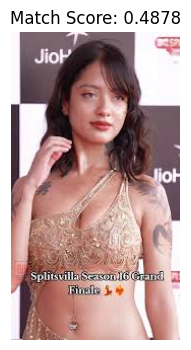

download.jpeg --> 0.4474


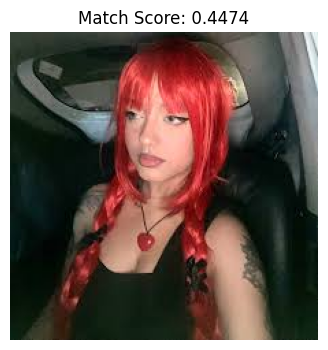

download (1).jpeg --> 0.4092


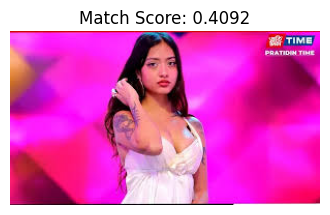

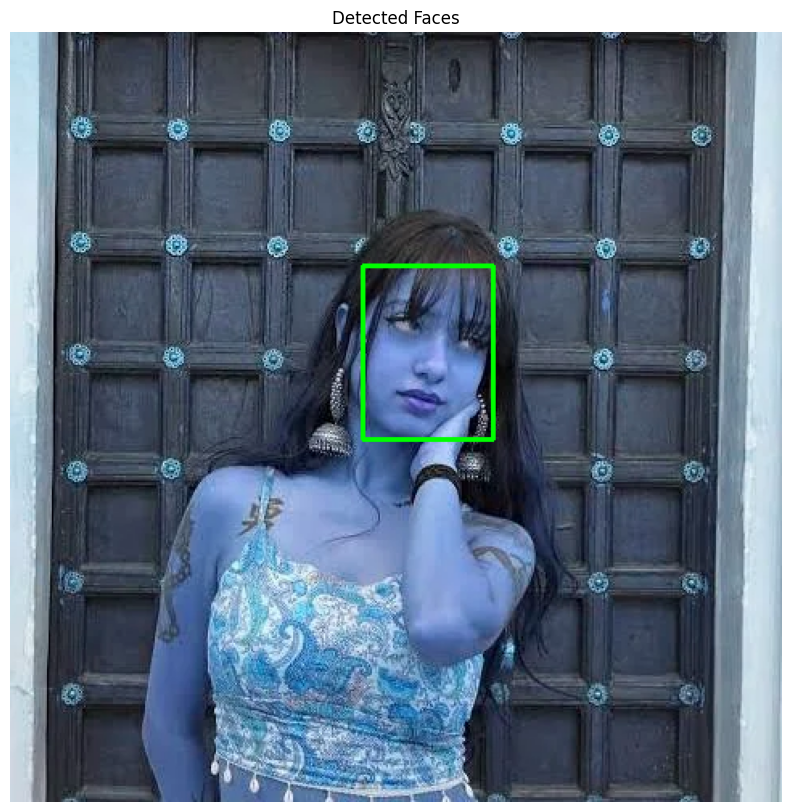

In [ ]:
img_copy = query_img.copy()

for face_num, face in enumerate(faces):

    print(f"\n========== FACE {face_num+1} ==========\n")

    # DRAW BOUNDING BOX

    box = face.bbox.astype(int)

    x1, y1, x2, y2 = box

    cv2.rectangle(
        img_copy,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    # FACE EMBEDDING

    query_embedding = face.embedding
    query_embedding = np.array([query_embedding]).astype(np.float32)

    faiss.normalize_L2(query_embedding)

    # SEARCH

    k = 3

    distances, indices = index.search(query_embedding, k)

    print("Top Matches:\n")

    for i in range(k):

        idx = indices[0][i]
        score = distances[0][i]

        filename = image_names[idx]

        print(f"{filename} --> {score:.4f}")

        # SHOW MATCHED IMAGE

        path = os.path.join(folder, filename)

        matched_img = cv2.imread(path)
        matched_img = cv2.cvtColor(
            matched_img,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(4,4))
        plt.imshow(matched_img)
        plt.title(f"Match Score: {score:.4f}")
        plt.axis("off")
        plt.show()

# SHOW QUERY IMAGE

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Detected Faces")
plt.axis("off")
plt.show()